In [303]:
import numpy as np
from PIL import Image
from matplotlib import image, pyplot

In [304]:
import json
import re

TESTFILENAME = "jacob_3"

testImage = ''
with open((TESTFILENAME + '.json'), 'r') as f:
    testImage = json.load(f)

# print(testImage)
# print(testImage['handedness'])


# testImage.hand_landmarks

In [305]:
# Some Magic
class HashmapObj:
    def __init__(self, in_dict:dict):
        assert isinstance(in_dict, dict)
        for key, val in in_dict.items():
            if isinstance(val, (list, tuple)):
                setattr(self, key, [HashmapObj(x) if isinstance(x, dict) else x for x in val])
            else:
                setattr(self, key, HashmapObj(val) if isinstance(val, dict) else val)

In [306]:
timg = HashmapObj(testImage)
# timg['handedness']
# timg.handednes
# timg.hand_landmarks[0]
# timg.hand_landmarks[0][0]['x']
temporalImageArray = []
for point in timg.hand_landmarks[0]:
    # print(point)
    # print(point['x']*255, point['y']*255, point['z']*127)
    temporalImageArray.append((int(point['x']*255), int(point['y']*255), int(((point['z'] + 1) / 2) * 255)))
    # temporalImageArray.append((int(point['x']*255), int(point['y']*255), 0))
temporalImageArray = np.array([temporalImageArray])
# print(temporalImageArray)
# temporalImageArray = np.array([[(point['x']*255, point['y']*255, point['z']*127) for point in timg.hand_landmarks[0]]])
# print(temporalImageArray)
# print(temporalImageArray.shape)
temporalImage = Image.fromarray(temporalImageArray, 'RGB')
# plt.imshow(temporalImageArray)
temporalImage.save(TESTFILENAME+'_out.jpg')





In [307]:
# im = np.array(Image.open('adam_test_1.jpg'))
# im.shape
# im[0,0]
# im[0:100,0:100] = [255, 0, 0]
# pyplot.imshow(im)
# Image.fromarray(im).save('jacob.jpg')

In [ ]:
import os
IMAGE_FILES = os.listdir('./input_images')
print(IMAGE_FILES)

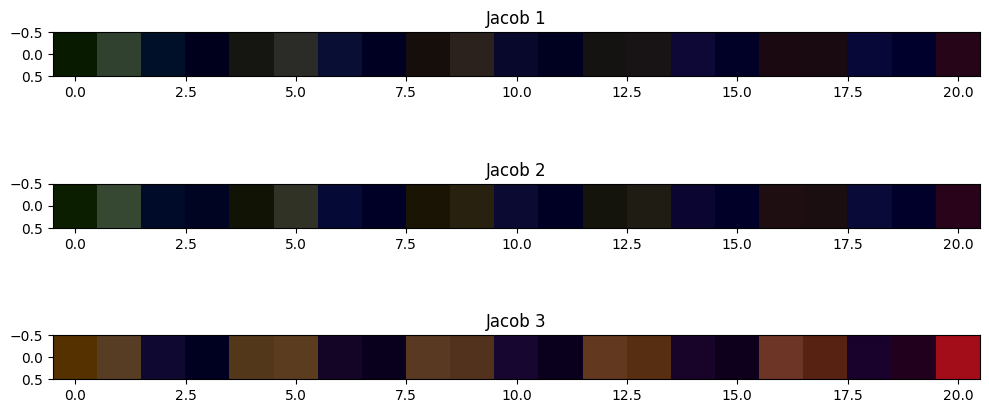

In [335]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

labeledOrOut = 'out'
# Load the images
img1 = mpimg.imread(f'jacob_1_{labeledOrOut}.jpg')
img2 = mpimg.imread(f'jacob_2_{labeledOrOut}.jpg')
img3 = mpimg.imread(f'jacob_3_{labeledOrOut}.jpg')

imgarr = np.array([img1, img2, img3])
# print(img1)

imgarr_list = imgarr.tolist()

# Save the list to a JSON file
with open('imgarr.json', 'w') as f:
    json.dump(imgarr_list, f)

# Create a subplot with 2 rows and 1 column
fig, axs = plt.subplots(3, 1, figsize=(10, 5))

# Display the first image on the first subplot
axs[0].imshow(img1)
axs[0].set_title('Jacob 1')
# axs[0].axis('off')  # Hide the axis

# Display the second image on the second subplot
axs[1].imshow(img2)
axs[1].set_title('Jacob 2')
# axs[1].axis('off')  # Hide the axis

# Display the second image on the second subplot
axs[2].imshow(img3)
axs[2].set_title('Jacob 3')
# axs[2].axis('off')  # Hide the axis

# Show the plot
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


['WIN_20240902_23_17_13_Pro.jpg', 'WIN_20240902_23_17_14_Pro.jpg', 'WIN_20240902_23_17_15_Pro.jpg', 'WIN_20240902_23_17_16_Pro (2).jpg', 'WIN_20240902_23_17_16_Pro.jpg', 'WIN_20240902_23_17_17_Pro.jpg']
